In [1]:
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from itertools import product
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import numpy as np
import pandas as pd

In [2]:
from utils import DataHandler
from ESN import ESNetwork
from reservoirs import CPRC

In [3]:
def compute_memory_capacity_explicit(reservoir_states, input_signal, max_delay=100, ridge_alpha=1e-6):
    """
    Computes memory capacity based on the explicit definition from arXiv:2403.08998.

    Parameters:
        reservoir_states (np.ndarray): Reservoir states of shape (T, N)
        input_signal (np.ndarray): Original input signal (1D array of length T)
        max_delay (int): Maximum delay to compute memory for
        ridge_alpha (float): Regularization strength for Ridge regression

    Returns:
        total_memory_capacity (float): Sum of per-delay memory scores
        memory_scores (list): List of memory capacity C^τ_STM per delay
    """
    memory_scores = []

    for tau in range(1, max_delay + 1):
        X = reservoir_states[tau:]
        y_target = input_signal[:-tau]

        # Train readout
        model = Ridge(alpha=ridge_alpha)
        model.fit(X, y_target)
        y_pred = model.predict(X)

        cov = np.cov(y_pred, y_target, bias=True)[0, 1]
        var_pred = np.var(y_pred)
        var_target = np.var(y_target)

        c_tau = (cov ** 2) / (var_pred * var_target) if var_pred > 0 and var_target > 0 else 0.0
        memory_scores.append(c_tau)

    total_memory_capacity = np.sum(memory_scores)
    return total_memory_capacity, memory_scores

In [4]:
def run_single_trial(w, i, tau=17, n_samples=10000, tr=0.75):
    # Load dataset
    X, Y = DataHandler().load_dataset('mackey_glass', n_samples=n_samples, tau=tau, window_size=w, prediction_horizon=1, plot=False)
    train_size = int(n_samples * tr)
    X_train_, X_test_ = X[:train_size], X[train_size:]
    y_train, y_test = Y[:train_size], Y[train_size:]

    # Normalize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_)
    # X_test = scaler.transform(X_test_)

    dim = X_train.shape[1]
    CP_params = [0.1499956344663278, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]
    # Build reservoir + network
    cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
    esn = ESNetwork(
        reservoir=cprc,
        dim=dim,
        regularization=1e-6,
        alpha=0.79,
        show_progress=False,
        approach='feedback',
        model_type='ridge',
        limit=0.95,
        cpk=True
    )
    
    esn.fit(X_train, y_train, washout=200)
    y_train_post_washout = y_train[200:]

    quantum_states = esn.get_saved_states()
    memory_capacity, r2_scores = compute_memory_capacity_explicit(quantum_states, y_train_post_washout)
    print(f"Memory Capacity: {memory_capacity}, for w= {w}")

    return {
        'window_size': w,
        'trial': i,
        'memory_capacity': memory_capacity,
        'r2_scores': r2_scores
    }

In [5]:
window_sizes = list(range(5, 26, 5))    
tau = 17
itr=len(window_sizes)
n_samples = 10000

results = Parallel(n_jobs=-1)(
    delayed(run_single_trial)(w, i, tau=tau, n_samples=n_samples)
    for w in tqdm(window_sizes, desc="Window sizes")
    for i in range(itr)
)


indow sizes: 100%|███████████████████████████████| 5/5 [05:54<00:00, 70.98s/it]

Memory Capacity: 43.87921602562186, for w= 5
Memory Capacity: 65.31696849713387, for w= 10
Memory Capacity: 98.21358582732704, for w= 20
Memory Capacity: 43.87921602562186, for w= 5
Memory Capacity: 91.59000119001406, for w= 15
Memory Capacity: 98.21358582732704, for w= 20
Memory Capacity: 43.87921602562186, for w= 5
Memory Capacity: 91.59000119001406, for w= 15
Memory Capacity: 98.21358582732704, for w= 20
Memory Capacity: 43.87921602562186, for w= 5
Memory Capacity: 91.59000119001406, for w= 15
Memory Capacity: 98.78600870734653, for w= 25
Memory Capacity: 65.31696849713387, for w= 10
Memory Capacity: 91.59000119001406, for w= 15
Memory Capacity: 98.78600870734653, for w= 25
Memory Capacity: 65.31696849713387, for w= 10
Memory Capacity: 91.59000119001406, for w= 15
Memory Capacity: 98.78600870734653, for w= 25


In [6]:
df = pd.DataFrame(results)
df.to_csv("mc_vs_window_parallel.csv", index=False)

In [2]:
df = pd.read_csv("mc_vs_window_parallel.csv")

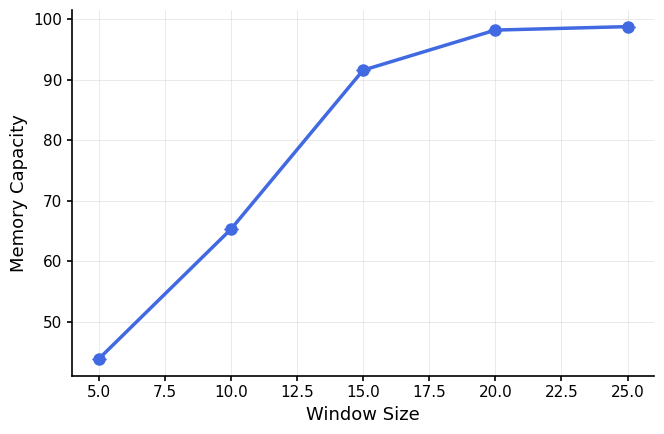

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":          12,
    "axes.titlesize":     14,
    "axes.labelsize":     13,
    "legend.fontsize":    11,
    "xtick.labelsize":    11,
    "ytick.labelsize":    11,
    "lines.linewidth":    2.5,
    "lines.markersize":   8,
    "axes.linewidth":     1.2,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.6,
    "xtick.major.width":  1.2,
    "ytick.major.width":  1.2,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
})

mean_mc = df.groupby("window_size")["memory_capacity"].mean()
std_mc  = df.groupby("window_size")["memory_capacity"].std()

fig, ax = plt.subplots(figsize=(6.8, 4.5))   # double-column width
ax.errorbar(
    mean_mc.index,
    mean_mc.values,
    yerr=std_mc.values,          
    fmt='o-', capsize=5,
    color='royalblue',
    ecolor='royalblue', elinewidth=1.5,
)
ax.set_xlabel("Window Size")
ax.set_ylabel("Memory Capacity")
plt.tight_layout()
plt.savefig("figures/memory_capacity_vs_window_size.pdf")
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv("mc_vs_window_parallel.csv")

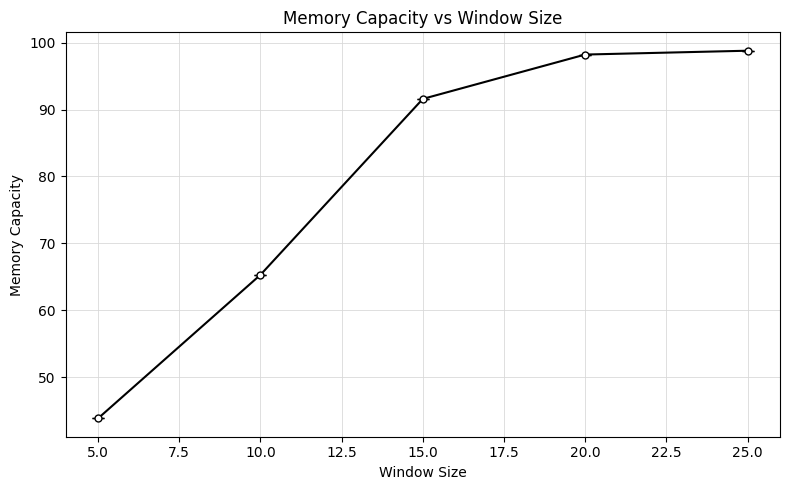

In [4]:
from matplotlib import pyplot as plt

mean_mc = df.groupby("window_size")["memory_capacity"].mean()
std_mc  = df.groupby("window_size")["memory_capacity"].std()

plt.figure(figsize=(8, 5))

# Monochrome styling
plt.errorbar(
    mean_mc.index,           # x values (window sizes)
    mean_mc.values,          # y values (mean MC)
    yerr=std_mc.values,      # vertical error bars
    fmt='o-',                # circle markers + solid line
    markersize=5,
    markerfacecolor='white', # hollow markers for B/W clarity
    markeredgecolor='black',
    color='black',
    ecolor='black',
    elinewidth=1.2,
    capsize=4,
    linewidth=1.5
)

plt.xlabel("Window Size")
plt.ylabel("Memory Capacity")
plt.title("Memory Capacity vs Window Size")
plt.grid(True, which='both', linewidth=0.6, color='0.85')  # light gray grid
plt.tight_layout()

# Vector PDF for patent submissions; add a 600-dpi TIFF if needed
plt.savefig("figures/wb_memory_capacity_vs_window_size.pdf")
plt.show()
